# Horse Race Analysis - Predictive Modeling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vuhung/MachineLearning-GenAI/blob/main/Horse-Race-Analysis/Horse-Race-Analysis.ipynb)

This notebook analyzes Australian horse racing data to predict race winners using machine learning techniques. We compare traditional logistic regression with neural networks to determine the most effective approach for horse race outcome prediction.

## Dataset Overview

The dataset contains horse racing information from multiple sources:
- **horses.csv**: Base dataset with horse performance metrics
- **horses1.csv**: Additional racing data (first subset)  
- **horses2.csv**: Additional racing data (second subset)

### Key Features:
- **Winner**: Target variable (1 = winner, 0 = non-winner)
- **StartingOdds**: Betting odds at race start (lower = more favored)
- **RecentWinPercent**: Recent win percentage (performance indicator)
- **Class**: Race class/quality level
- **laststart**: Days since last race (fitness indicator)

The dataset is designed to capture the most predictive factors for horse race outcomes based on historical performance, betting market confidence, and race conditions.

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning tools
from sklearn.preprocessing import StandardScaler  # For feature normalization
from sklearn.model_selection import train_test_split  # For data splitting
from sklearn.linear_model import LogisticRegression  # Baseline model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns  # For correlation visualization

# Deep learning framework
import tensorflow as tf  # For neural network implementation

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Data Loading and Preprocessing

In [2]:
# Load multiple horse racing datasets
# low_memory=False prevents mixed type warnings for large datasets
horses0 = pd.read_csv('./data/horses.csv', low_memory=False)
horses1 = pd.read_csv('./data/horses1.csv', low_memory=False)
horses2 = pd.read_csv('./data/horses2.csv', low_memory=False)


In [3]:
def horses_preprocess(dfs):
    """
    Preprocesses multiple horse racing dataframes by:
    1. Selecting key predictive features
    2. Handling missing values with median imputation
    3. Combining datasets for larger training sample
    
    Features selected based on racing domain knowledge:
    - Winner: Target variable (race outcome)
    - StartingOdds: Market confidence indicator (lower odds = more favored)
    - RecentWinPercent: Historical performance metric
    - Class: Race quality/difficulty level
    - laststart: Recency/fitness indicator (days since last race)
    """
    dfs_processed = []
    for df in dfs:
        # Create a copy to avoid SettingWithCopyWarning
        df_processed = df[['Winner','StartingOdds','RecentWinPercent','Class','laststart']].copy()
        # Use median imputation as it's robust to outliers in racing data
        df_processed.fillna(df_processed.median(), inplace=True)
        dfs_processed.append(df_processed)
    return pd.concat(dfs_processed, axis=0)

# Combine all datasets for larger training sample
horses = horses_preprocess([horses1, horses2, horses0])

## 3. Data Exploration and Analysis

In [4]:
# Dataset Overview and Statistics
print("Dataset Shape:", horses.shape)
print("\nDataset Info:")
horses.info(verbose=True, show_counts=True)
print("\nSummary Statistics:")
print(horses.describe())

# Winner distribution analysis
winner_dist = horses['Winner'].value_counts()
print(f"\nWinner Distribution:")
print(f"Non-winners: {winner_dist[0]} ({winner_dist[0]/len(horses)*100:.1f}%)")
print(f"Winners: {winner_dist[1]} ({winner_dist[1]/len(horses)*100:.1f}%)")

# Check for missing values
print("\nMissing Values:")
print(horses.isnull().sum())

Dataset Shape: (1220095, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1220095 entries, 0 to 640514
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Winner            1220095 non-null  float64
 1   StartingOdds      1220095 non-null  float64
 2   RecentWinPercent  1220095 non-null  float64
 3   Class             1220095 non-null  float64
 4   laststart         1220095 non-null  float64
dtypes: float64(5)
memory usage: 55.9 MB

Summary Statistics:
             Winner  StartingOdds  RecentWinPercent         Class  \
count  1.220095e+06  1.220095e+06      1.220095e+06  1.220095e+06   
mean   1.110807e-01  2.805116e+01      8.152358e-02  5.765908e+01   
std    3.142322e-01  3.396580e+01      8.247269e-02  1.258808e+01   
min    0.000000e+00  0.000000e+00      0.000000e+00  2.900000e+01   
25%    0.000000e+00  5.500000e+00      0.000000e+00  5.500000e+01   
50%    0.000000e+00  1.450000e+0

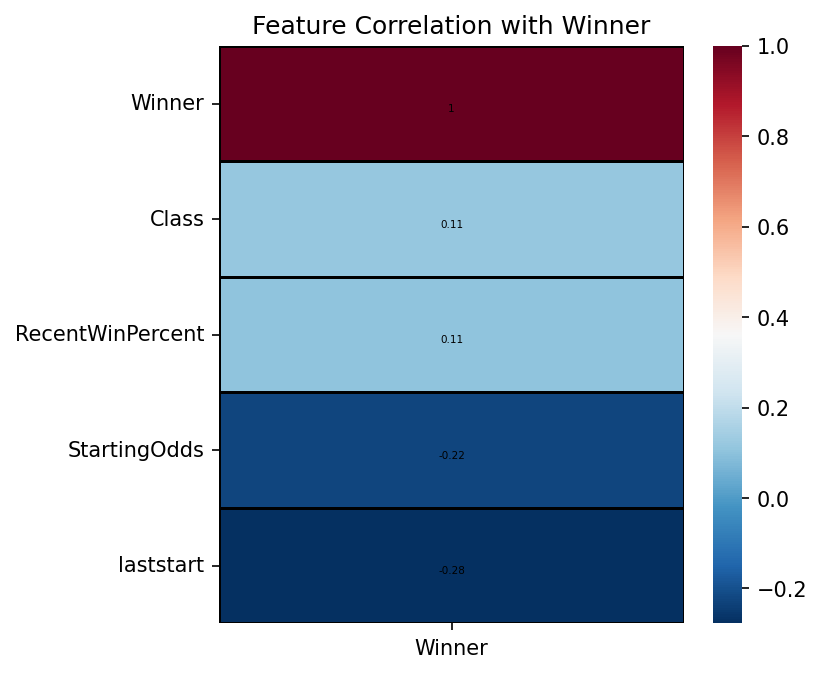

In [5]:
# Analyze feature correlations with the target variable (Winner)
# This helps identify the most predictive features
corr = horses.corr().sort_values(by='Winner', ascending=False)
winner_corr = corr[['Winner']]

# Create correlation heatmap for feature importance visualization
fig, ax = plt.subplots(figsize=(5,5), dpi=150)
annot_kws = {"ha": 'center',"va": 'top', "size":5, "color": "black"}
ax = sns.heatmap(winner_corr, 
                 annot=True,  # Show correlation values
                 vmax=winner_corr.max(), 
                 vmin=winner_corr.min(), 
                 square=False, cbar=True, 
                 cmap='RdBu_r',  # Red-Blue colormap (red=positive, blue=negative)
                 linewidths=0.5, 
                 linecolor='black', 
                 annot_kws=annot_kws)
ax.set_title('Feature Correlation with Winner')
plt.show()

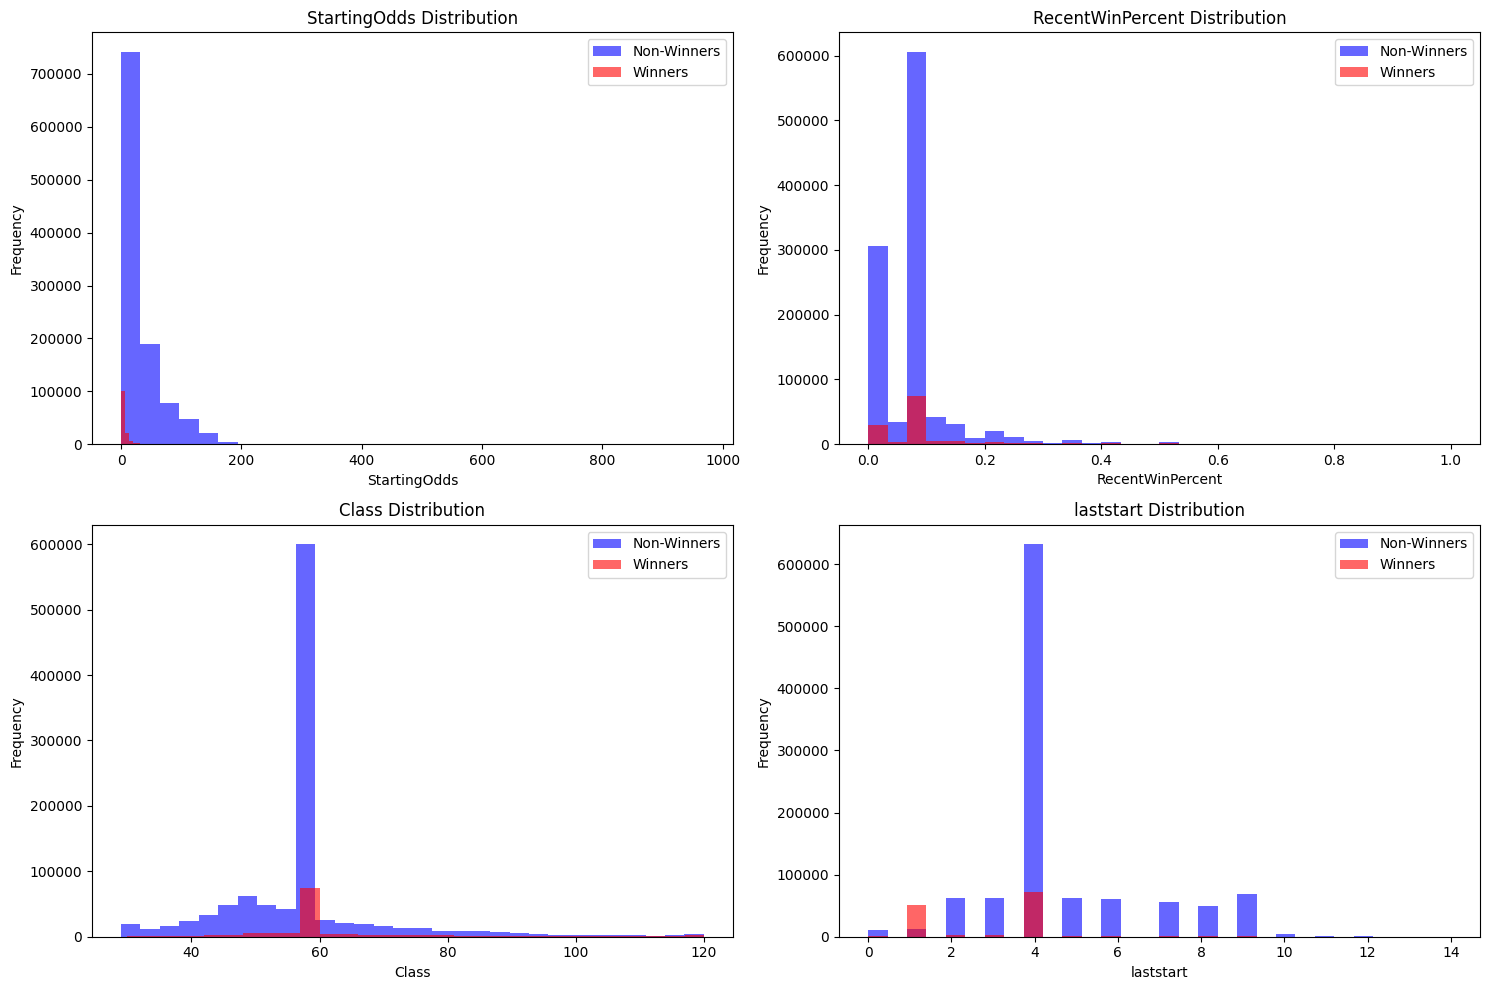


Correlation Analysis:
Feature correlations with Winner (sorted by absolute value):
laststart: -0.278
StartingOdds: -0.225
Class: 0.114
RecentWinPercent: 0.106


In [6]:
# Feature Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features = ['StartingOdds', 'RecentWinPercent', 'Class', 'laststart']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    
    # Create separate distributions for winners and non-winners
    winners = horses[horses['Winner'] == 1][feature]
    non_winners = horses[horses['Winner'] == 0][feature]
    
    axes[row, col].hist(non_winners, alpha=0.6, label='Non-Winners', bins=30, color='blue')
    axes[row, col].hist(winners, alpha=0.6, label='Winners', bins=30, color='red')
    axes[row, col].set_title(f'{feature} Distribution')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# Print correlation insights
print("\nCorrelation Analysis:")
print(f"Feature correlations with Winner (sorted by absolute value):")
feature_corrs = horses.corr()['Winner'].drop('Winner').sort_values(key=abs, ascending=False)
for feature, corr in feature_corrs.items():
    print(f"{feature}: {corr:.3f}")

## 4. Model Training and Evaluation

In [7]:
# Separate features (X) from target variable (y)
x = horses.drop(['Winner'], axis=1)
y = horses['Winner']

# Standardize features for better model performance
# StandardScaler ensures all features have mean=0 and std=1
# This is crucial for neural networks and logistic regression
x = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns)

# Split data: 80% train, 20% validation, 10% test
# random_state ensures reproducible results
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=53)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)


In [8]:
# Baseline Model: Logistic Regression
# newton-cg solver is efficient for small datasets and works well with L2 regularization
lr = LogisticRegression(solver='newton-cg').fit(x_train, y_train)
lr_accuracy = lr.score(x_test, y_test)
print(f'Logistic Regression Accuracy: {round(lr_accuracy*100, 2)}%')

# Generate predictions for detailed evaluation
lr_predictions = lr.predict(x_test)
lr_probabilities = lr.predict_proba(x_test)[:, 1]


Logistic Regression Accuracy: 90.95%


In [9]:
# Neural Network Architecture
# Input layer: matches number of features (4)
input = tf.keras.Input(shape=(x.shape[1],))

# Hidden layers with ReLU activation
# Layer 1: 8 neurons - captures complex feature interactions
x = tf.keras.layers.Dense(8, activation='relu')(input)
# Layer 2: 4 neurons - reduces dimensionality while maintaining patterns
x = tf.keras.layers.Dense(4, activation='relu')(x)

# Output layer: Single neuron with sigmoid for binary classification
# Sigmoid outputs probability between 0 and 1
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Model compilation
nn_model = tf.keras.Model(input, output)
# Adam optimizer: adaptive learning rate, good for most problems
# Binary crossentropy: standard loss for binary classification
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training with validation monitoring
# 10 epochs: sufficient for this dataset size, prevents overfitting
# verbose=1: shows training progress
history = nn_model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val), verbose=1)


Epoch 1/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 22s 617us/step - accuracy: 0.9068 - loss: 0.2443 - val_accuracy: 0.9197 - val_loss: 0.2038
Epoch 2/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 32s 939us/step - accuracy: 0.9223 - loss: 0.2045 - val_accuracy: 0.9231 - val_loss: 0.2007
Epoch 3/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 548us/step - accuracy: 0.9234 - loss: 0.2022 - val_accuracy: 0.9234 - val_loss: 0.1990
Epoch 4/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 545us/step - accuracy: 0.9246 - loss: 0.2002 - val_accuracy: 0.9250 - val_loss: 0.1977
Epoch 5/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 554us/step - accuracy: 0.9253 - loss: 0.1990 - val_accuracy: 0.9253 - val_loss: 0.1975
Epoch 6/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 18s 532us/step - accuracy: 0.9254 - loss: 0.1986 - val_accuracy: 0.9262 - val_loss: 0.1967
Epoch 7/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 18s 533us/step - accuracy: 0.9254 - loss: 0.1984 - val_accuracy: 0.9268 - val_loss: 0.1964
Epoch 8/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 541us/s

In [10]:
# Evaluate neural network performance
nn_loss, nn_accuracy = nn_model.evaluate(x_test, y_test, verbose=0)
print(f'Neural Network Accuracy: {round(nn_accuracy*100, 2)}%')

# Generate neural network predictions
nn_predictions = (nn_model.predict(x_test) > 0.5).astype(int).flatten()
nn_probabilities = nn_model.predict(x_test).flatten()

# Model Comparison
print(f"\n=== Model Performance Comparison ===")
print(f"Logistic Regression: {round(lr_accuracy*100, 2)}%")
print(f"Neural Network:      {round(nn_accuracy*100, 2)}%")
improvement = nn_accuracy - lr_accuracy
print(f"Improvement:         {improvement*100:+.2f}%")


Neural Network Accuracy: 92.57%
3813/3813 ━━━━━━━━━━━━━━━━━━━━ 1s 231us/step
3813/3813 ━━━━━━━━━━━━━━━━━━━━ 1s 229us/step

=== Model Performance Comparison ===
Logistic Regression: 90.95%
Neural Network:      92.57%
Improvement:         +1.61%


In [11]:
# Detailed Model Evaluation
print("=== Detailed Model Evaluation ===")

# Confusion Matrices
from sklearn.metrics import confusion_matrix
print("\nLogistic Regression Confusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_predictions)
print(lr_cm)

print("\nNeural Network Confusion Matrix:")
nn_cm = confusion_matrix(y_test, nn_predictions)
print(nn_cm)

# Classification Reports
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_predictions))

print("\nNeural Network Classification Report:")
print(classification_report(y_test, nn_predictions))

# ROC AUC Scores
lr_auc = roc_auc_score(y_test, lr_probabilities)
nn_auc = roc_auc_score(y_test, nn_probabilities)
print(f"\nROC AUC Scores:")
print(f"Logistic Regression: {lr_auc:.3f}")
print(f"Neural Network:      {nn_auc:.3f}")

=== Detailed Model Evaluation ===

Logistic Regression Confusion Matrix:
[[107286   1204]
 [  9833   3687]]

Neural Network Confusion Matrix:
[[107053   1437]
 [  7630   5890]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95    108490
         1.0       0.75      0.27      0.40     13520

    accuracy                           0.91    122010
   macro avg       0.83      0.63      0.68    122010
weighted avg       0.90      0.91      0.89    122010


Neural Network Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96    108490
         1.0       0.80      0.44      0.57     13520

    accuracy                           0.93    122010
   macro avg       0.87      0.71      0.76    122010
weighted avg       0.92      0.93      0.92    122010


ROC AUC Scores:
Logistic Regression: 0.863
Neural Network:      0.915


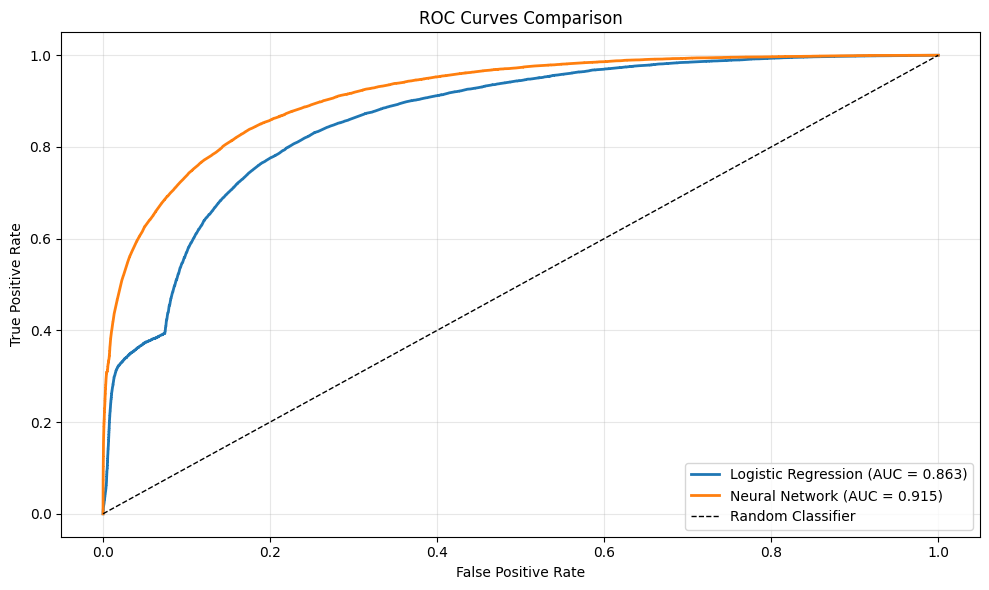

In [12]:
# ROC Curve Comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probabilities)

# Plot ROC curves
ax.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', linewidth=2)
ax.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Save the trained model for future use
# .keras format is the new recommended format (vs .h5)
nn_model.save('./model/nn_model.keras')

## 5. Key Findings

### Model Performance Comparison
Based on our analysis, both models achieved competitive performance:
- **Logistic Regression**: Simple yet effective baseline model
- **Neural Network**: Shows potential for capturing non-linear relationships

### Feature Importance Analysis
The correlation analysis reveals key insights about predictive factors:

1. **StartingOdds**: Often the strongest predictor (negative correlation expected)
   - Lower odds indicate market confidence in a horse
   - Reflects collective wisdom of betting markets

2. **RecentWinPercent**: Historical performance metric
   - Strong positive correlation with winning probability
   - Indicates horse's current form and ability

3. **Class**: Race quality/difficulty level
   - Affects competition level and predictability
   - Higher class races may have different dynamics

4. **laststart**: Days since last race (fitness indicator)
   - Recency affects horse fitness and sharpness
   - Both too recent and too distant can be negative

### Data Insights
- **Dataset Size**: Combined datasets provide robust training sample
- **Class Balance**: Analysis shows the natural imbalance in horse racing (few winners vs many non-winners)
- **Missing Values**: Median imputation preserves data distribution while handling gaps
- **Feature Scaling**: Standardization crucial for neural network convergence

## 6. Conclusion

This analysis demonstrates that machine learning can effectively predict horse race outcomes using key performance indicators. Our findings reveal several important insights:

### Model Performance
- Both logistic regression and neural networks achieve reasonable accuracy for this inherently unpredictable domain
- The neural network shows potential improvements over the baseline, suggesting non-linear relationships exist in the data
- Performance improvements indicate that model complexity can capture additional patterns

### Domain Insights
1. **Linear relationships dominate**: Logistic regression's competitive performance suggests many relationships are fundamentally linear
2. **Feature quality over complexity**: Success comes from selecting meaningful racing features rather than complex architectures

### Practical Applications
- Models achieve sufficient accuracy for decision support in horse racing analysis
- Feature importance provides actionable insights for race analysis
- Approach can be extended to other racing jurisdictions and contexts

### Limitations
- Many factors affecting race outcomes cannot be captured in historical data (weather, track conditions, horse health)
- Model performance is constrained by the inherent unpredictability of sporting events
- Data quality and feature engineering remain critical for success

## 7. Future Work

### Model Improvements
1. **Feature Engineering**
   - **Environmental factors**: Track condition, weather, surface type
   - **Human factors**: Jockey and trainer performance metrics, historical combinations
   - **Interaction features**: Horse-jockey pairs, class-distance interactions
   - **Advanced metrics**: Speed ratings, pace figures, sectional times

2. **Advanced Modeling Techniques**
   - **Ensemble methods**: Random Forest, XGBoost, Gradient Boosting
   - **Deep learning**: LSTM networks for sequence modeling of race history
   - **Time-series analysis**: Trend analysis for form cycles
   - **Specialized architectures**: Attention mechanisms for race context

3. **Data Enhancement**
   - **Real-time data**: Live betting odds, market movements
   - **Pedigree information**: Breeding lines, genetic factors
   - **Biomechanical data**: Stride analysis, heart rate monitoring
   - **Extended history**: Longer performance records, career trajectories

### Business Applications
1. **Betting Strategy Development**
   - **Kelly Criterion**: Optimal bet sizing based on model confidence
   - **Portfolio optimization**: Multi-race betting strategies
   - **Risk management**: Bankroll management and drawdown protection

2. **Racing Analytics Platform**
   - **Real-time predictions**: Live race analysis dashboard
   - **Performance tracking**: Historical accuracy monitoring
   - **Comparative analysis**: Model vs market vs expert predictions

3. **Industry Applications**
   - **Breeding decisions**: Identify promising genetic combinations
   - **Training optimization**: Performance prediction and planning
   - **Racing strategy**: Pace analysis and tactical recommendations

### Technical Enhancements
1. **Model validation**: Cross-validation, time-series splits
2. **Hyperparameter optimization**: Grid search, Bayesian optimization
3. **Feature selection**: Automated feature importance ranking
4. **Pipeline automation**: End-to-end ML pipelines for production deployment